In [1]:
# ==========================================
# CELL 1 - IMPORT LIBRARIES
# ==========================================

# Basic libraries
import os
import random
import numpy as np
import pandas as pd

# Image processing
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image data pipeline
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Transfer learning
from tensorflow.keras.applications import EfficientNetB0

# Training callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==========================================
# Environment Check
# ==========================================

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

All libraries imported successfully!
TensorFlow version: 2.18.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ==========================================
# CELL 2 - PROJECT & DATASET PATHS
# ==========================================

PROJECT_DIR = os.getcwd()

# Dataset folders
DATASET_1 = os.path.join(PROJECT_DIR, "Dataset-1")
DATASET_2 = os.path.join(PROJECT_DIR, "Dataset-2")

# Dataset-1
D1_MRI = os.path.join(DATASET_1, "MRI")
D1_CT = os.path.join(DATASET_1, "CT")

# Dataset-2
D2_MRI = os.path.join(DATASET_2, "MRI")
D2_CT = os.path.join(DATASET_2, "CT")

# ==========================================
# Verify Paths
# ==========================================

paths = {
    "Dataset-1": DATASET_1,
    "Dataset-1 MRI": D1_MRI,
    "Dataset-1 CT": D1_CT,
    "Dataset-2": DATASET_2,
    "Dataset-2 MRI": D2_MRI,
    "Dataset-2 CT": D2_CT
}

for name, path in paths.items():
    print(f"{name:<18}: {path}")
    print(f"{'Exists':<18}: {os.path.exists(path)}\n")

Dataset-1         : /Users/akhibshaik/Desktop/Project/Dataset-1
Exists            : True

Dataset-1 MRI     : /Users/akhibshaik/Desktop/Project/Dataset-1/MRI
Exists            : True

Dataset-1 CT      : /Users/akhibshaik/Desktop/Project/Dataset-1/CT
Exists            : True

Dataset-2         : /Users/akhibshaik/Desktop/Project/Dataset-2
Exists            : True

Dataset-2 MRI     : /Users/akhibshaik/Desktop/Project/Dataset-2/MRI
Exists            : True

Dataset-2 CT      : /Users/akhibshaik/Desktop/Project/Dataset-2/CT
Exists            : True



In [3]:
# ==========================================
# CELL 3 - CONFIGURATION & DATASET COUNTS
# ==========================================

SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Class names
CLASS_NAMES = ["Healthy", "Tumor"]

# ==========================================
# Count Images
# ==========================================

def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    
    return sum(
        1
        for root, _, files in os.walk(folder)
        for file in files
        if file.lower().endswith(extensions)
    )


dataset_counts = {
    "Dataset-1 MRI Healthy": count_images(os.path.join(D1_MRI, "Healthy")),
    "Dataset-1 MRI Tumor": count_images(os.path.join(D1_MRI, "Tumor")),
    "Dataset-1 CT Healthy": count_images(os.path.join(D1_CT, "Healthy")),
    "Dataset-1 CT Tumor": count_images(os.path.join(D1_CT, "Tumor")),
    "Dataset-2 MRI Healthy": count_images(os.path.join(D2_MRI, "Healthy")),
    "Dataset-2 MRI Tumor": count_images(os.path.join(D2_MRI, "Tumor")),
    "Dataset-2 CT Healthy": count_images(os.path.join(D2_CT, "Healthy")),
    "Dataset-2 CT Tumor": count_images(os.path.join(D2_CT, "Tumor")),
}

print("Image configuration:")
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", CLASS_NAMES)
print("Seed       :", SEED)

print("\nDataset counts:")
for name, count in dataset_counts.items():
    print(f"{name:<28}: {count}")

Image configuration:
Image size : (224, 224)
Batch size : 32
Classes    : ['Healthy', 'Tumor']
Seed       : 42

Dataset counts:
Dataset-1 MRI Healthy       : 5600
Dataset-1 MRI Tumor         : 5900
Dataset-1 CT Healthy        : 5620
Dataset-1 CT Tumor          : 5662
Dataset-2 MRI Healthy       : 2000
Dataset-2 MRI Tumor         : 3000
Dataset-2 CT Healthy        : 2300
Dataset-2 CT Tumor          : 2318


In [4]:
# ==========================================
# CELL 4 - CREATE DATAFRAMES
# ==========================================

def create_dataframe(modality_path):
    filepaths = []
    labels = []

    for class_name in CLASS_NAMES:
        class_path = os.path.join(modality_path, class_name)

        for filename in os.listdir(class_path):
            filepath = os.path.join(class_path, filename)

            if os.path.isfile(filepath):
                filepaths.append(filepath)
                labels.append(class_name)

    return pd.DataFrame({
        "filepath": filepaths,
        "label": labels
    })


# ==========================================
# Dataset-1 DataFrames
# ==========================================

d1_mri_df = create_dataframe(D1_MRI)
d1_ct_df = create_dataframe(D1_CT)


# ==========================================
# Dataset-2 DataFrames
# ==========================================

d2_mri_df = create_dataframe(D2_MRI)
d2_ct_df = create_dataframe(D2_CT)


# ==========================================
# Display Summary
# ==========================================

print("Dataset-1 MRI:", len(d1_mri_df))
print("Dataset-1 CT :", len(d1_ct_df))
print("Dataset-2 MRI:", len(d2_mri_df))
print("Dataset-2 CT :", len(d2_ct_df))

print("\nDataset-1 MRI class distribution:")
print(d1_mri_df["label"].value_counts())

print("\nDataset-1 CT class distribution:")
print(d1_ct_df["label"].value_counts())

print("\nDataset-2 MRI class distribution:")
print(d2_mri_df["label"].value_counts())

print("\nDataset-2 CT class distribution:")
print(d2_ct_df["label"].value_counts())

Dataset-1 MRI: 11500
Dataset-1 CT : 11282
Dataset-2 MRI: 5000
Dataset-2 CT : 4618

Dataset-1 MRI class distribution:
label
Tumor      5900
Healthy    5600
Name: count, dtype: int64

Dataset-1 CT class distribution:
label
Tumor      5662
Healthy    5620
Name: count, dtype: int64

Dataset-2 MRI class distribution:
label
Tumor      3000
Healthy    2000
Name: count, dtype: int64

Dataset-2 CT class distribution:
label
Tumor      2318
Healthy    2300
Name: count, dtype: int64


In [5]:
# ==========================================
# CELL 5 - TRAIN / VALIDATION SPLIT
# ==========================================

# MRI split
mri_train, mri_val = train_test_split(
    d1_mri_df,
    test_size=0.20,
    stratify=d1_mri_df["label"],
    random_state=SEED
)

# CT split
ct_train, ct_val = train_test_split(
    d1_ct_df,
    test_size=0.20,
    stratify=d1_ct_df["label"],
    random_state=SEED
)

# Reset indices
mri_train = mri_train.reset_index(drop=True)
mri_val = mri_val.reset_index(drop=True)

ct_train = ct_train.reset_index(drop=True)
ct_val = ct_val.reset_index(drop=True)


# ==========================================
# Display Split Sizes
# ==========================================

print("MRI:")
print(f"  Training   : {len(mri_train)}")
print(f"  Validation : {len(mri_val)}")

print("\nCT:")
print(f"  Training   : {len(ct_train)}")
print(f"  Validation : {len(ct_val)}")


# ==========================================
# Verify Class Distribution
# ==========================================

print("\nMRI training distribution:")
print(mri_train["label"].value_counts())

print("\nMRI validation distribution:")
print(mri_val["label"].value_counts())

print("\nCT training distribution:")
print(ct_train["label"].value_counts())

print("\nCT validation distribution:")
print(ct_val["label"].value_counts())

MRI:
  Training   : 9200
  Validation : 2300

CT:
  Training   : 9025
  Validation : 2257

MRI training distribution:
label
Tumor      4720
Healthy    4480
Name: count, dtype: int64

MRI validation distribution:
label
Tumor      1180
Healthy    1120
Name: count, dtype: int64

CT training distribution:
label
Tumor      4529
Healthy    4496
Name: count, dtype: int64

CT validation distribution:
label
Tumor      1133
Healthy    1124
Name: count, dtype: int64


In [6]:
# ==========================================
# CELL 6 - IMAGE DATA GENERATORS
# ==========================================

# No additional augmentation
mri_datagen = ImageDataGenerator()
ct_datagen = ImageDataGenerator()


# ==========================================
# MRI Generators
# ==========================================

mri_train_generator = mri_datagen.flow_from_dataframe(
    dataframe=mri_train,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

mri_val_generator = mri_datagen.flow_from_dataframe(
    dataframe=mri_val,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ==========================================
# CT Generators
# ==========================================

ct_train_generator = ct_datagen.flow_from_dataframe(
    dataframe=ct_train,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

ct_val_generator = ct_datagen.flow_from_dataframe(
    dataframe=ct_val,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ==========================================
# Class Mapping
# ==========================================

print("\nClass mapping:")
print("MRI:", mri_train_generator.class_indices)
print("CT :", ct_train_generator.class_indices)

Found 9200 validated image filenames belonging to 2 classes.
Found 2300 validated image filenames belonging to 2 classes.
Found 9025 validated image filenames belonging to 2 classes.
Found 2257 validated image filenames belonging to 2 classes.

Class mapping:
MRI: {'Healthy': 0, 'Tumor': 1}
CT : {'Healthy': 0, 'Tumor': 1}


In [8]:
# ==========================================
# CELL 7 - MRI EFFICIENTNETB0 MODEL
# ==========================================

# Load pretrained EfficientNetB0
base_model_mri = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model_mri.trainable = False


# ==========================================
# Build MRI Classification Model
# ==========================================

mri_model = keras.Sequential([
    base_model_mri,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])


# ==========================================
# Compile Model
# ==========================================

mri_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)


# ==========================================
# Model Summary
# ==========================================

mri_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
# ==========================================
# CELL 8 - TRAIN MRI MODEL
# ==========================================

EPOCHS_MRI = 10

# Stop if validation loss does not improve
early_stopping_mri = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr_mri = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Save the best MRI model
checkpoint_mri = ModelCheckpoint(
    "mri_efficientnet_baseline.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ==========================================
# Start Training
# ==========================================

mri_history = mri_model.fit(
    mri_train_generator,
    validation_data=mri_val_generator,
    epochs=EPOCHS_MRI,
    callbacks=[
        early_stopping_mri,
        reduce_lr_mri,
        checkpoint_mri
    ]
)

Epoch 1/10


2026-09-03 15:15:32.841121: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8472 - auc: 0.9312 - loss: 0.3459 - precision: 0.8553 - recall: 0.8451 
Epoch 1: val_loss improved from None to 0.20272, saving model to mri_efficientnet_baseline.keras

Epoch 1: finished saving model to mri_efficientnet_baseline.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 68s 219ms/step - accuracy: 0.8472 - auc: 0.9312 - loss: 0.3459 - precision: 0.8553 - recall: 0.8451 - val_accuracy: 0.9261 - val_auc: 0.9815 - val_loss: 0.2027 - val_precision: 0.9346 - val_recall: 0.9203 - learning_rate: 1.0000e-04
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9203 - auc: 0.9771 - loss: 0.2020 - precision: 0.9246 - recall: 0.9197 
Epoch 2: val_loss improved from 0.20272 to 0.15789, saving model to mri_efficientnet_baseline.keras

Epoch 2: finished saving model to mri_efficientnet_baseline.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 60s 206ms/step - accuracy: 0.9203 - auc: 0.9771 - loss: 0.2020 - precision: 0.9246 - recall: 0.9197 - val_acc

72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step
MRI MODEL - DATASET-1 VALIDATION
              precision    recall  f1-score   support

     Healthy     0.9583    0.9643    0.9613      1120
       Tumor     0.9659    0.9602    0.9630      1180

    accuracy                         0.9622      2300
   macro avg     0.9621    0.9622    0.9622      2300
weighted avg     0.9622    0.9622    0.9622      2300

Overall Metrics
--------------------------------------------------
Accuracy : 0.9622
Precision: 0.9659
Recall   : 0.9602
F1 Score : 0.9630
AUC      : 0.9958


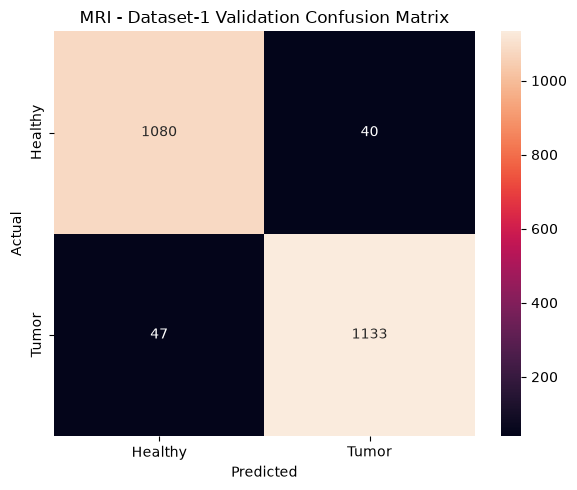

In [10]:
# ==========================================
# CELL 9 - MRI MODEL EVALUATION
# ==========================================

# Generate predictions
mri_val_generator.reset()

mri_probabilities = mri_model.predict(
    mri_val_generator,
    verbose=1
).ravel()

# Convert probabilities to class predictions
mri_predictions = (mri_probabilities >= 0.5).astype(int)

# True labels
mri_true_labels = mri_val_generator.classes


# ==========================================
# Classification Report
# ==========================================

print("MRI MODEL - DATASET-1 VALIDATION")
print("=" * 50)

print(
    classification_report(
        mri_true_labels,
        mri_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)


# ==========================================
# Overall Metrics
# ==========================================

mri_accuracy = accuracy_score(
    mri_true_labels,
    mri_predictions
)

mri_precision = precision_score(
    mri_true_labels,
    mri_predictions
)

mri_recall = recall_score(
    mri_true_labels,
    mri_predictions
)

mri_f1 = f1_score(
    mri_true_labels,
    mri_predictions
)

mri_auc = roc_auc_score(
    mri_true_labels,
    mri_probabilities
)

print("Overall Metrics")
print("-" * 50)
print(f"Accuracy : {mri_accuracy:.4f}")
print(f"Precision: {mri_precision:.4f}")
print(f"Recall   : {mri_recall:.4f}")
print(f"F1 Score : {mri_f1:.4f}")
print(f"AUC      : {mri_auc:.4f}")


# ==========================================
# Confusion Matrix
# ==========================================

cm_mri = confusion_matrix(
    mri_true_labels,
    mri_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_mri,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MRI - Dataset-1 Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# CELL 10 - CT EFFICIENTNETB0 MODEL
# ==========================================

# Load pretrained EfficientNetB0
base_model_ct = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model_ct.trainable = False


# ==========================================
# Build CT Classification Model
# ==========================================

ct_model = keras.Sequential([
    base_model_ct,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])


# ==========================================
# Compile Model
# ==========================================

ct_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)


# ==========================================
# Model Summary
# ==========================================

ct_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
# ==========================================
# CELL 11 - TRAIN CT MODEL
# ==========================================

EPOCHS_CT = 10

# Stop if validation loss does not improve
early_stopping_ct = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr_ct = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Save the best CT model
checkpoint_ct = ModelCheckpoint(
    "ct_efficientnet_baseline.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ==========================================
# Start Training
# ==========================================

ct_history = ct_model.fit(
    ct_train_generator,
    validation_data=ct_val_generator,
    epochs=EPOCHS_CT,
    callbacks=[
        early_stopping_ct,
        reduce_lr_ct,
        checkpoint_ct
    ]
)

Epoch 1/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8398 - auc: 0.9166 - loss: 0.3719 - precision: 0.8596 - recall: 0.8136 
Epoch 1: val_loss improved from None to 0.23476, saving model to ct_efficientnet_baseline.keras

Epoch 1: finished saving model to ct_efficientnet_baseline.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 77s 251ms/step - accuracy: 0.8398 - auc: 0.9166 - loss: 0.3719 - precision: 0.8596 - recall: 0.8136 - val_accuracy: 0.9269 - val_auc: 0.9681 - val_loss: 0.2348 - val_precision: 0.9481 - val_recall: 0.9038 - learning_rate: 1.0000e-04
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9039 - auc: 0.9602 - loss: 0.2504 - precision: 0.9282 - recall: 0.8764 
Epoch 2: val_loss improved from 0.23476 to 0.19036, saving model to ct_efficientnet_baseline.keras

Epoch 2: finished saving model to ct_efficientnet_baseline.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 63s 220ms/step - accuracy: 0.9039 - auc: 0.9602 - loss: 0.2504 - precision: 0.9282 - recall: 0.8764 - 

71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step
CT MODEL - DATASET-1 VALIDATION
              precision    recall  f1-score   support

     Healthy     0.9298    0.9786    0.9536      1124
       Tumor     0.9777    0.9267    0.9515      1133

    accuracy                         0.9526      2257
   macro avg     0.9537    0.9527    0.9526      2257
weighted avg     0.9538    0.9526    0.9526      2257

Overall Metrics
--------------------------------------------------
Accuracy : 0.9526
Precision: 0.9777
Recall   : 0.9267
F1 Score : 0.9515
AUC      : 0.9878


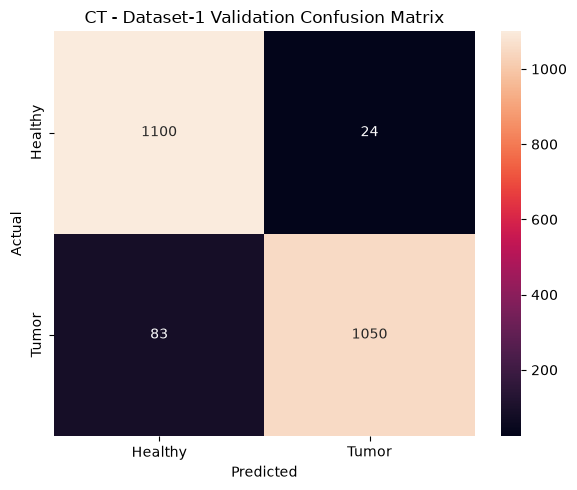

In [13]:
# ==========================================
# CELL 12 - CT MODEL EVALUATION
# ==========================================

# Generate predictions
ct_val_generator.reset()

ct_probabilities = ct_model.predict(
    ct_val_generator,
    verbose=1
).ravel()

# Convert probabilities to class predictions
ct_predictions = (ct_probabilities >= 0.5).astype(int)

# True labels
ct_true_labels = ct_val_generator.classes


# ==========================================
# Classification Report
# ==========================================

print("CT MODEL - DATASET-1 VALIDATION")
print("=" * 50)

print(
    classification_report(
        ct_true_labels,
        ct_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)


# ==========================================
# Overall Metrics
# ==========================================

ct_accuracy = accuracy_score(
    ct_true_labels,
    ct_predictions
)

ct_precision = precision_score(
    ct_true_labels,
    ct_predictions
)

ct_recall = recall_score(
    ct_true_labels,
    ct_predictions
)

ct_f1 = f1_score(
    ct_true_labels,
    ct_predictions
)

ct_auc = roc_auc_score(
    ct_true_labels,
    ct_probabilities
)

print("Overall Metrics")
print("-" * 50)
print(f"Accuracy : {ct_accuracy:.4f}")
print(f"Precision: {ct_precision:.4f}")
print(f"Recall   : {ct_recall:.4f}")
print(f"F1 Score : {ct_f1:.4f}")
print(f"AUC      : {ct_auc:.4f}")


# ==========================================
# Confusion Matrix
# ==========================================

cm_ct = confusion_matrix(
    ct_true_labels,
    ct_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_ct,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CT - Dataset-1 Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# CELL 13 - DATASET-2 TEST GENERATORS
# ==========================================

# Test generator - no augmentation
d2_datagen = ImageDataGenerator()


# ==========================================
# Dataset-2 MRI Test Generator
# ==========================================

d2_mri_generator = d2_datagen.flow_from_dataframe(
    dataframe=d2_mri_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ==========================================
# Dataset-2 CT Test Generator
# ==========================================

d2_ct_generator = d2_datagen.flow_from_dataframe(
    dataframe=d2_ct_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    classes=CLASS_NAMES,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ==========================================
# Display Test Set Information
# ==========================================

print("\nDataset-2 Test Sets")
print("=" * 40)

print(f"MRI test images: {d2_mri_generator.samples}")
print(f"CT test images : {d2_ct_generator.samples}")

print("\nClass mapping:")
print("MRI:", d2_mri_generator.class_indices)
print("CT :", d2_ct_generator.class_indices)

Found 5000 validated image filenames belonging to 2 classes.
Found 4618 validated image filenames belonging to 2 classes.

Dataset-2 Test Sets
MRI test images: 5000
CT test images : 4618

Class mapping:
MRI: {'Healthy': 0, 'Tumor': 1}
CT : {'Healthy': 0, 'Tumor': 1}


157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 182ms/step
MRI CROSS-DATASET RESULTS
              precision    recall  f1-score   support

     Healthy     0.9685    0.9690    0.9688      2000
       Tumor     0.9793    0.9790    0.9792      3000

    accuracy                         0.9750      5000
   macro avg     0.9739    0.9740    0.9740      5000
weighted avg     0.9750    0.9750    0.9750      5000

Overall Metrics
--------------------------------------------------
Accuracy : 0.9750
Precision: 0.9793
Recall   : 0.9790
F1 Score : 0.9792
AUC      : 0.9979


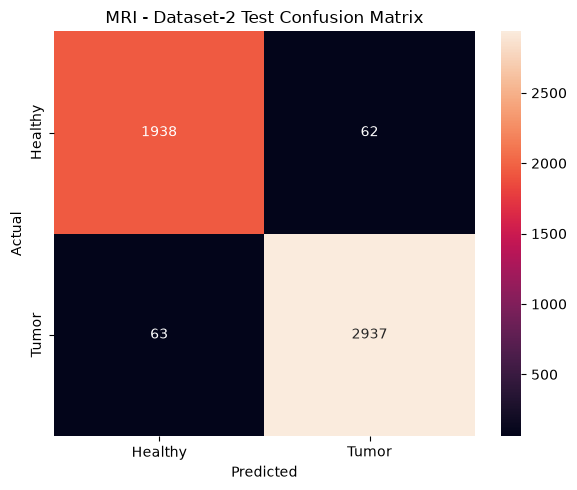

In [18]:
# ==========================================
# CELL 14 - MRI CROSS-DATASET TEST
# ==========================================

# Reset generator to ensure predictions start from the first image
d2_mri_generator.reset()

# Generate tumor probabilities
d2_mri_probabilities = mri_model.predict(
    d2_mri_generator,
    verbose=1
).ravel()

# Convert probabilities to binary predictions
d2_mri_predictions = (
    d2_mri_probabilities >= 0.5
).astype(int)

# True labels
d2_mri_true_labels = d2_mri_generator.classes


# ==========================================
# Calculate Metrics
# ==========================================

d2_mri_accuracy = accuracy_score(
    d2_mri_true_labels,
    d2_mri_predictions
)

d2_mri_precision = precision_score(
    d2_mri_true_labels,
    d2_mri_predictions
)

d2_mri_recall = recall_score(
    d2_mri_true_labels,
    d2_mri_predictions
)

d2_mri_f1 = f1_score(
    d2_mri_true_labels,
    d2_mri_predictions
)

d2_mri_auc = roc_auc_score(
    d2_mri_true_labels,
    d2_mri_probabilities
)


# ==========================================
# Display Results
# ==========================================

print("MRI CROSS-DATASET RESULTS")
print("=" * 50)

print(
    classification_report(
        d2_mri_true_labels,
        d2_mri_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

print("Overall Metrics")
print("-" * 50)
print(f"Accuracy : {d2_mri_accuracy:.4f}")
print(f"Precision: {d2_mri_precision:.4f}")
print(f"Recall   : {d2_mri_recall:.4f}")
print(f"F1 Score : {d2_mri_f1:.4f}")
print(f"AUC      : {d2_mri_auc:.4f}")


# ==========================================
# Confusion Matrix
# ==========================================

cm_d2_mri = confusion_matrix(
    d2_mri_true_labels,
    d2_mri_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_d2_mri,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MRI - Dataset-2 Test Confusion Matrix")
plt.tight_layout()
plt.show()

145/145 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step
CT CROSS-DATASET RESULTS
              precision    recall  f1-score   support

     Healthy     0.9412    0.9804    0.9604      2300
       Tumor     0.9797    0.9392    0.9590      2318

    accuracy                         0.9597      4618
   macro avg     0.9604    0.9598    0.9597      4618
weighted avg     0.9605    0.9597    0.9597      4618

Overall Metrics
--------------------------------------------------
Accuracy : 0.9597
Precision: 0.9797
Recall   : 0.9392
F1 Score : 0.9590
AUC      : 0.9921


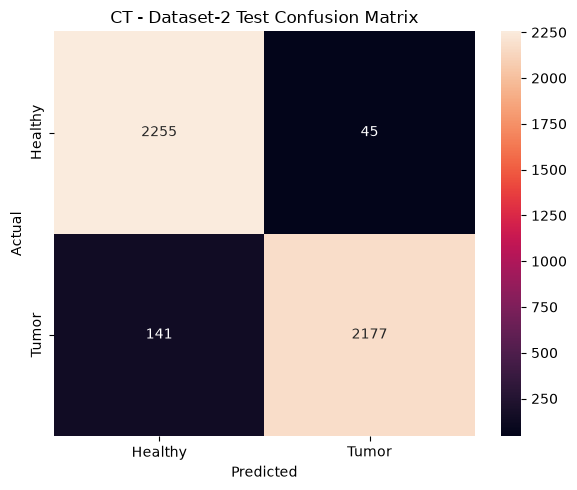

In [19]:
# ==========================================
# CELL 15 - CT CROSS-DATASET TEST
# ==========================================

# Reset generator
d2_ct_generator.reset()

# Generate tumor probabilities
d2_ct_probabilities = ct_model.predict(
    d2_ct_generator,
    verbose=1
).ravel()

# Convert probabilities to binary predictions
d2_ct_predictions = (
    d2_ct_probabilities >= 0.5
).astype(int)

# True labels
d2_ct_true_labels = d2_ct_generator.classes


# ==========================================
# Calculate Metrics
# ==========================================

d2_ct_accuracy = accuracy_score(
    d2_ct_true_labels,
    d2_ct_predictions
)

d2_ct_precision = precision_score(
    d2_ct_true_labels,
    d2_ct_predictions
)

d2_ct_recall = recall_score(
    d2_ct_true_labels,
    d2_ct_predictions
)

d2_ct_f1 = f1_score(
    d2_ct_true_labels,
    d2_ct_predictions
)

d2_ct_auc = roc_auc_score(
    d2_ct_true_labels,
    d2_ct_probabilities
)


# ==========================================
# Display Results
# ==========================================

print("CT CROSS-DATASET RESULTS")
print("=" * 50)

print(
    classification_report(
        d2_ct_true_labels,
        d2_ct_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

print("Overall Metrics")
print("-" * 50)
print(f"Accuracy : {d2_ct_accuracy:.4f}")
print(f"Precision: {d2_ct_precision:.4f}")
print(f"Recall   : {d2_ct_recall:.4f}")
print(f"F1 Score : {d2_ct_f1:.4f}")
print(f"AUC      : {d2_ct_auc:.4f}")


# ==========================================
# Confusion Matrix
# ==========================================

cm_d2_ct = confusion_matrix(
    d2_ct_true_labels,
    d2_ct_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_d2_ct,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CT - Dataset-2 Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# CELL 16 - COMPARE CROSS-DATASET RESULTS
# ==========================================

comparison_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    "MRI": [
        d2_mri_accuracy,
        d2_mri_precision,
        d2_mri_recall,
        d2_mri_f1,
        d2_mri_auc
    ],
    "CT": [
        d2_ct_accuracy,
        d2_ct_precision,
        d2_ct_recall,
        d2_ct_f1,
        d2_ct_auc
    ]
})

# Round for display
comparison_display = comparison_results.copy()

comparison_display["MRI"] = comparison_display["MRI"].round(4)
comparison_display["CT"] = comparison_display["CT"].round(4)

print("CROSS-DATASET PERFORMANCE: DATASET-2")
print("=" * 55)

display(comparison_display)

CROSS-DATASET PERFORMANCE: DATASET-2


,Metric,MRI,CT
0,Accuracy,0.9750,0.9597
1,Precision,0.9793,0.9797
2,Recall,0.9790,0.9392
3,F1 Score,0.9792,0.9590
4,AUC,0.9979,0.9921


In [24]:
# ==========================================
# CELL 17 - USER MRI + CT PREDICTION
# ==========================================

from tkinter import Tk, filedialog


# ==========================================
# Function to Select an Image
# ==========================================

def select_image(title):

    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)

    file_path = filedialog.askopenfilename(
        title=title,
        filetypes=[
            ("Image files", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff"),
            ("All files", "*.*")
        ]
    )

    root.destroy()

    return file_path


# ==========================================
# Function to Predict Tumor Probability
# ==========================================

def predict_probability(model, image_path):

    image = keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    image_array = keras.utils.img_to_array(image)

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probability = model.predict(
        image_array,
        verbose=0
    )[0][0]

    return float(probability)


# ==========================================
# STEP 1 - ASK FOR MRI
# ==========================================

print("=" * 60)
print("STEP 1: SELECT MRI SCAN")
print("=" * 60)

mri_path = select_image(
    "Select MRI Scan"
)

if not mri_path:

    print("No MRI scan selected.")
    
else:

    print("MRI selected:")
    print(os.path.basename(mri_path))


# ==========================================
# STEP 2 - ASK FOR CT
# ==========================================

if mri_path:

    print("\n" + "=" * 60)
    print("STEP 2: SELECT CT SCAN")
    print("=" * 60)

    ct_path = select_image(
        "Select CT Scan"
    )

    if not ct_path:

        print("No CT scan selected.")

    else:

        print("CT selected:")
        print(os.path.basename(ct_path))


        # ==================================
        # STEP 3 - MRI PREDICTION
        # ==================================

        mri_probability = predict_probability(
            mri_model,
            mri_path
        )


        # ==================================
        # STEP 4 - CT PREDICTION
        # ==================================

        ct_probability = predict_probability(
            ct_model,
            ct_path
        )


        # ==================================
        # STEP 5 - LATE FUSION
        # ==================================

        MRI_WEIGHT = 0.5
        CT_WEIGHT = 0.5

        fused_probability = (
            MRI_WEIGHT * mri_probability
            + CT_WEIGHT * ct_probability
        )


        # ==================================
        # STEP 6 - FINAL DECISION
        # ==================================

        if fused_probability >= 0.5:
            final_prediction = "Tumor"
        else:
            final_prediction = "Healthy"


        # ==================================
        # DISPLAY RESULTS
        # ==================================

        print("\n")
        print("=" * 60)
        print("MULTIMODAL PREDICTION RESULT")
        print("=" * 60)

        print(
            f"MRI Tumor Probability : "
            f"{mri_probability:.4f} "
            f"({mri_probability * 100:.2f}%)"
        )

        print(
            f"CT Tumor Probability  : "
            f"{ct_probability:.4f} "
            f"({ct_probability * 100:.2f}%)"
        )

        print("-" * 60)

        print(
            f"MRI Weight            : "
            f"{MRI_WEIGHT:.2f}"
        )

        print(
            f"CT Weight             : "
            f"{CT_WEIGHT:.2f}"
        )

        print("-" * 60)

        print(
            f"Fused Tumor Probability: "
            f"{fused_probability:.4f} "
            f"({fused_probability * 100:.2f}%)"
        )

        print(
            f"FINAL PREDICTION      : "
            f"{final_prediction}"
        )

        print("=" * 60)

STEP 1: SELECT MRI SCAN
MRI selected:
mri_tumor.jpg

STEP 2: SELECT CT SCAN
CT selected:
ct_tumor.jpg


MULTIMODAL PREDICTION RESULT
MRI Tumor Probability : 0.9935 (99.35%)
CT Tumor Probability  : 0.9954 (99.54%)
------------------------------------------------------------
MRI Weight            : 0.50
CT Weight             : 0.50
------------------------------------------------------------
Fused Tumor Probability: 0.9944 (99.44%)
FINAL PREDICTION      : Tumor
